<a href="https://colab.research.google.com/github/ikeyareinaldosae/ITC501---Artificial-Intelligence-Applications/blob/main/Milestone%202%20Brief%3A%20AI%20for%20Non-tabular%20Data%20%7C%20Deep%20Learning/Milestone_2_Brief_AI_for_Non_tabular_Data_%7C_Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# ==========================================
# 0. GATHERING IMPORTS
# ==========================================

from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import seaborn as sns

In [5]:
# ==========================================
# 1. LOAD DATASET
# ==========================================

(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()

print(X_train.shape)
print(X_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5076s 30us/step
(50000, 32, 32, 3)
(10000, 32, 32, 3)


In [6]:
# ==========================================
# 2. NORMALIZE IMAGES
# ==========================================

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [7]:
# ==========================================
# 3. CREATE VALIDATION SET
# ==========================================

from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42
)

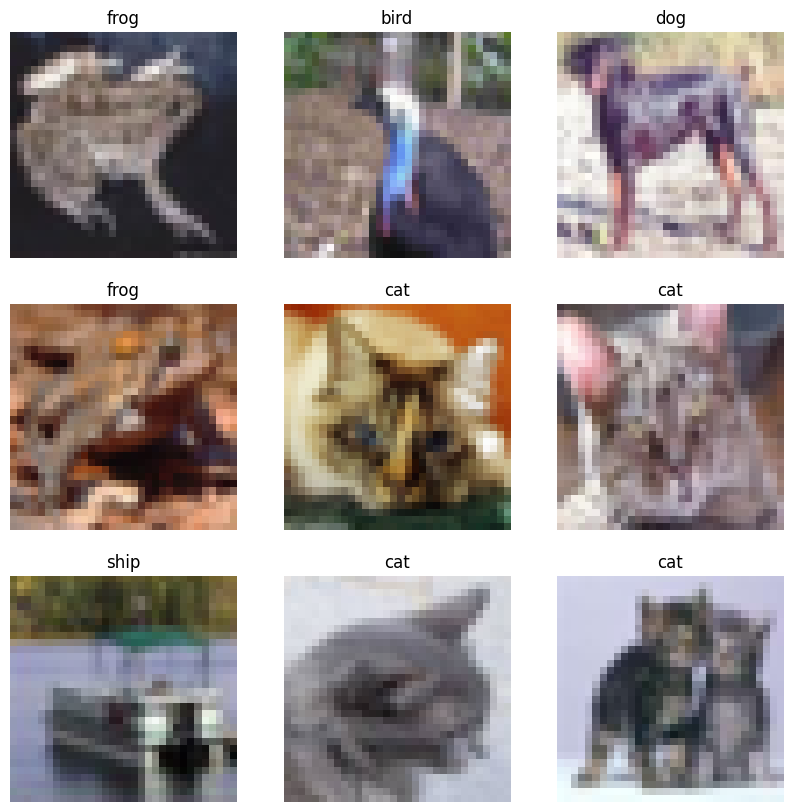

In [8]:
# ==========================================
# 4. VISUALIZE DATASET
# ==========================================

class_names = [
'airplane','automobile','bird','cat','deer',
'dog','frog','horse','ship','truck'
]

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')

plt.show()

In [9]:
# ==========================================
# 5. BUILD CNN MODEL
# ==========================================

model = models.Sequential()

model.add(layers.Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64,(3,3),activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64,(3,3),activation='relu'))

model.add(layers.Flatten())

model.add(layers.Dense(64,activation='relu'))

model.add(layers.Dense(10,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
# ==========================================
# 6. COMPILE MODEL
# ==========================================

model.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy']
)

In [11]:
# ==========================================
# 7. MODEL SUMMARY
# ==========================================

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# ==========================================
# 8. TRAIN MODEL
# ==========================================

history = model.fit(
X_train,
y_train,
epochs=15,
batch_size=64,
validation_data=(X_val,y_val)
)

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 56s 86ms/step - accuracy: 0.3957 - loss: 1.6404 - val_accuracy: 0.5079 - val_loss: 1.3734
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 52s 83ms/step - accuracy: 0.5304 - loss: 1.3121 - val_accuracy: 0.5680 - val_loss: 1.2115
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 53s 85ms/step - accuracy: 0.5912 - loss: 1.1452 - val_accuracy: 0.6043 - val_loss: 1.1335
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 54s 86ms/step - accuracy: 0.6334 - loss: 1.0442 - val_accuracy: 0.6258 - val_loss: 1.0557
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 54s 87ms/step - accuracy: 0.6612 - loss: 0.9697 - val_accuracy: 0.6612 - val_loss: 0.9814
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 80s 84ms/step - accuracy: 0.6811 - loss: 0.9119 - val_accuracy: 0.6605 - val_loss: 0.9666
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 85s 88ms/step - accuracy: 0.6990 - loss: 0.8555 - val_accuracy: 0.6842 - val_loss: 0.9048
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 80s 86ms/step - accuracy: 0.7160 - loss: 0.8103 - 

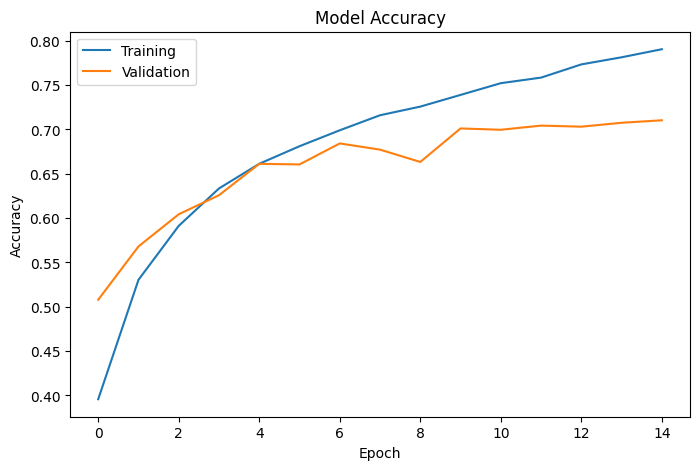

In [13]:
# ==========================================
# 9. PLOT ACCURACY
# ==========================================

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Training","Validation"])

plt.show()

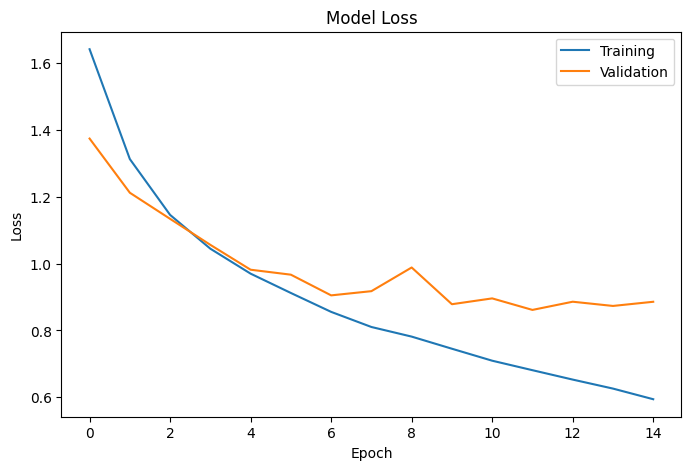

In [14]:
# ==========================================
# 10. PLOT LOSS
# ==========================================

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Training","Validation"])

plt.show()

In [15]:
# ==========================================
# 11. EVALUATE MODEL
# ==========================================

test_loss, test_accuracy = model.evaluate(X_test,y_test)

print("Test Accuracy:",test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7051 - loss: 0.8982
Test Accuracy: 0.7050999999046326


In [16]:
# ==========================================
# 12. MAKE PREDICTIONS
# ==========================================

predictions = model.predict(X_test)

predicted_classes = np.argmax(predictions,axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step


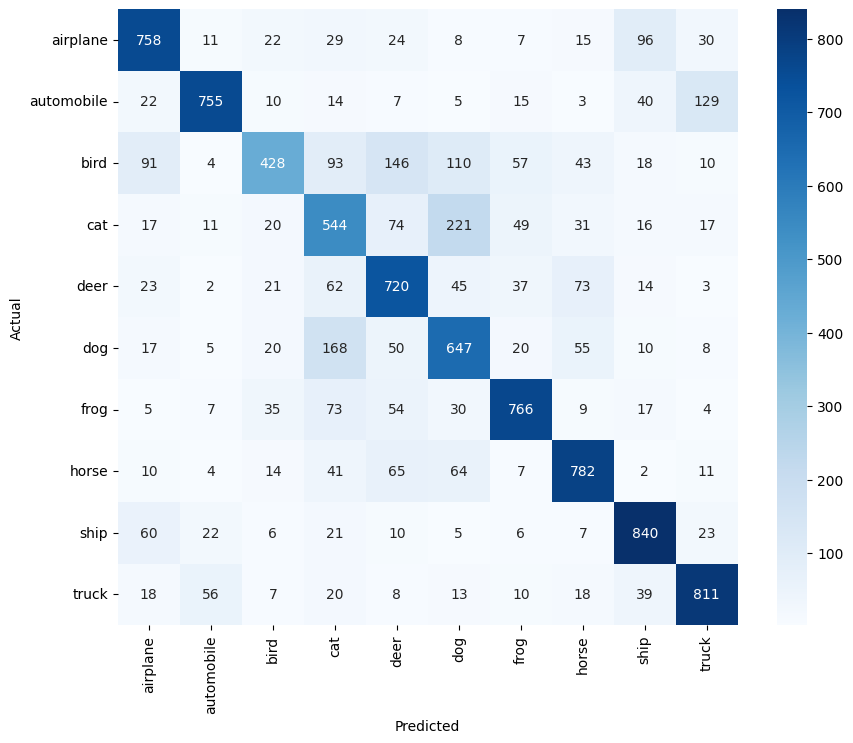

In [17]:
# ==========================================
# 13. CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(
y_test,
predicted_classes
)

plt.figure(figsize=(10,8))

sns.heatmap(
cm,
annot=True,
fmt='d',
cmap='Blues',
xticklabels=class_names,
yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [18]:
# ==========================================
# 14. CLASSIFICATION REPORT
# ==========================================

print(classification_report(
y_test,
predicted_classes,
target_names=class_names
))

              precision    recall  f1-score   support

    airplane       0.74      0.76      0.75      1000
  automobile       0.86      0.76      0.80      1000
        bird       0.73      0.43      0.54      1000
         cat       0.51      0.54      0.53      1000
        deer       0.62      0.72      0.67      1000
         dog       0.56      0.65      0.60      1000
        frog       0.79      0.77      0.78      1000
       horse       0.75      0.78      0.77      1000
        ship       0.77      0.84      0.80      1000
       truck       0.78      0.81      0.79      1000

    accuracy                           0.71     10000
   macro avg       0.71      0.71      0.70     10000
weighted avg       0.71      0.71      0.70     10000



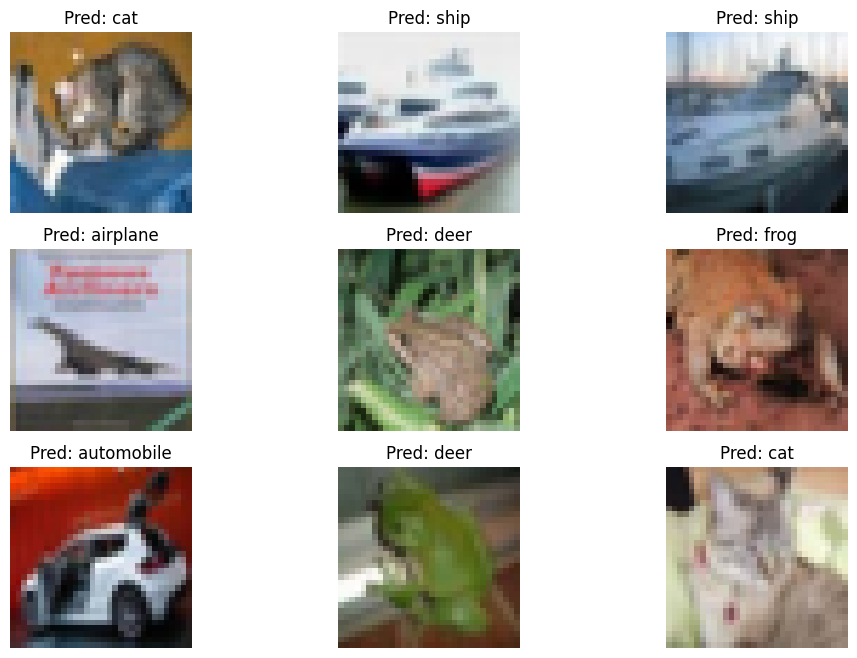

In [19]:
# ==========================================
# 15. PREDICT SAMPLE IMAGES
# ==========================================

plt.figure(figsize=(12,8))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(X_test[i])

    plt.title(
        "Pred: " + class_names[predicted_classes[i]]
    )

    plt.axis('off')

plt.show()